# Klasifikasi Kondisi Penggunaan Masker pada Citra Wajah Menggunakan Pengolahan Citra Digital dan Convolutional Neural Network

**Mata Kuliah:** Pengenalan Citra Digital  
**Topik:** Topik 5 — Klasifikasi Penggunaan Masker atau Kondisi Wajah Berdasarkan Citra

**Anggota Kelompok:**
1. Muhammad Wildan Hatami — G66401231009
2. Emi Purmawadi — G6401231032
3. M. Reyhan Hermawan — G6401231042
4. Hannan Azhari Batubara — G6401231052
5. Revandra Athaya Rizkika — G6401231125

**Tujuan Notebook:**
1. Mengunduh dan mengeksplorasi dataset "Face Mask Detection" dari Kaggle.
2. Memproses citra termasuk *resize* dan normalisasi.
3. Menerapkan *Image Enhancement* (CLAHE) untuk memperbaiki kontras citra.
4. Melakukan ekstraksi fitur klasik menggunakan *Histogram of Oriented Gradients* (HOG).
5. Melatih dan mengevaluasi model *Support Vector Machine* (SVM) sebagai *baseline*.
6. Membangun, melatih, dan mengevaluasi *Convolutional Neural Network* (CNN) sederhana buatan sendiri.
7. Membandingkan skenario dengan dan tanpa *enhancement*.
8. Melakukan analisis kesalahan dan demonstrasi interaktif.

In [ ]:
!pip install -q kagglehub

import os
import glob
import random
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import joblib
import kagglehub

from skimage.feature import hog
from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks

# Penetapan seed agar hasil reproduksibel
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("1. Seluruh library berhasil diimpor.")
print("2. Seed telah dikonfigurasi ke:", SEED)

1. Seluruh library berhasil diimpor.
2. Seed telah dikonfigurasi ke: 42


## Bagian C — Download Dataset dari Kaggle

Tahap ini mengunduh dataset menggunakan modul `kagglehub`. Setelah diunduh, sistem akan menelusuri direktori untuk mencari folder yang memuat citra. Hal ini dilakukan agar kode berjalan dinamis tanpa harus menebak jalur (*path*) folder yang pasti.

In [ ]:
# 1. Mengunduh dataset menggunakan kagglehub
print("Mengunduh dataset dari Kaggle...")
dataset_path = kagglehub.dataset_download("vijaykumar1799/face-mask-detection")
print("Dataset berhasil diunduh pada path:", dataset_path)

# 2. Menelusuri direktori untuk menemukan folder gambar
image_extensions = ('*.jpg', '*.jpeg', '*.png')
base_image_dir = None

for root, dirs, files in os.walk(dataset_path):
    # Cek apakah folder ini memuat banyak file gambar
    image_count = sum(1 for f in files if f.lower().endswith(('.jpg', '.jpeg', '.png')))
    if image_count > 100:
        # Jika folder ini punya banyak gambar, cek apakah ini folder kelas atau folder induk
        if len(dirs) > 0:
            base_image_dir = root
            break
        else:
            base_image_dir = os.path.dirname(root)
            break

if base_image_dir is None:
    base_image_dir = dataset_path # Fallback

print("Direktori utama citra dideteksi pada:", base_image_dir)

# 3. Mendata folder kelas yang tersedia
class_folders = [d for d in os.listdir(base_image_dir) if os.path.isdir(os.path.join(base_image_dir, d))]
print("Daftar kelas yang ditemukan:", class_folders)

Mengunduh dataset dari Kaggle...
Using Colab cache for faster access to the 'face-mask-detection' dataset.
Dataset berhasil diunduh pada path: /kaggle/input/face-mask-detection
Direktori utama citra dideteksi pada: /kaggle/input/face-mask-detection/Dataset
Daftar kelas yang ditemukan: ['without_mask', 'mask_weared_incorrect', 'with_mask']


## Bagian D — Eksplorasi Dataset

Proses ini bertujuan untuk memahami distribusi dataset. Informasi yang digali meliputi:
1. Jumlah citra pada masing-masing kelas.
2. Dimensi citra secara acak.
3. Mendeteksi file yang rusak.

Aspek yang perlu diamati secara visual:
1. Variasi pose wajah (depan, samping).
2. Perbedaan kondisi pencahayaan.
3. Adanya oklusi (halangan) selain masker.
4. Variasi latar belakang (*background*).

Total file gambar valid: 8982
Total file rusak: 0

Distribusi Kelas:
display_label
Tidak menggunakan masker                 2994
Menggunakan masker dengan tidak tepat    2994
Menggunakan masker dengan benar          2994
Name: count, dtype: int64


/tmp/ipykernel_19843/2242418301.py:54: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=class_counts.index, x=class_counts.values, palette="viridis", orient='h')


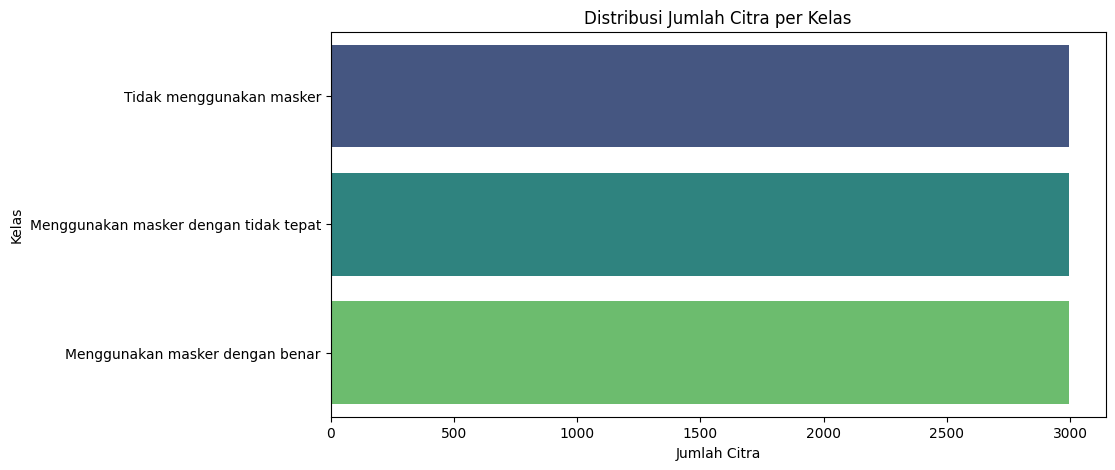

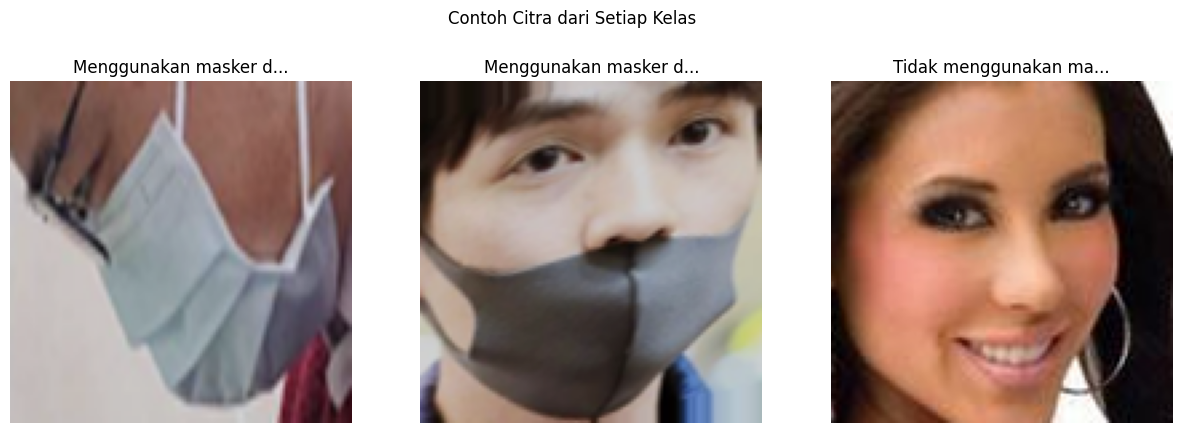

In [ ]:
filepaths = []
labels = []
corrupted_files = []

# 1. Membaca seluruh path gambar dan validasi file
for folder in class_folders:
    folder_path = os.path.join(base_image_dir, folder)
    files = glob.glob(os.path.join(folder_path, '*.*'))

    for f in files:
        if f.lower().endswith(('.png', '.jpg', '.jpeg')):
            try:
                # Validasi dengan PIL untuk memastikan gambar tidak rusak
                with Image.open(f) as img:
                    img.verify()
                filepaths.append(f)
                labels.append(folder)
            except Exception as e:
                corrupted_files.append(f)

# 2. Membuat DataFrame
df = pd.DataFrame({
    'filepath': filepaths,
    'folder_label': labels
})

print(f"Total file gambar valid: {len(df)}")
print(f"Total file rusak: {len(corrupted_files)}")

# 3. Mapping label agar rapi dalam Bahasa Indonesia
# Menyesuaikan dengan nama folder di Kaggle
label_mapping = {
    'with_mask': 'Menggunakan masker dengan benar',
    'without_mask': 'Tidak menggunakan masker',
    'mask_weared_incorrect': 'Menggunakan masker dengan tidak tepat'
}

# Jika nama folder di Kaggle berbeda dari standar di atas, sistem akan tetap menyimpannya dengan nama folder asli
df['display_label'] = df['folder_label'].map(lambda x: label_mapping.get(x, x))

# Buat mapping ID integer
unique_labels = sorted(df['display_label'].unique())
class_to_id = {label: i for i, label in enumerate(unique_labels)}
id_to_class = {i: label for i, label in enumerate(unique_labels)}

df['class_id'] = df['display_label'].map(class_to_id)

# 4. Menampilkan distribusi kelas
class_counts = df['display_label'].value_counts()
print("\nDistribusi Kelas:")
print(class_counts)

plt.figure(figsize=(10, 5))
sns.barplot(y=class_counts.index, x=class_counts.values, palette="viridis", orient='h')
plt.title("Distribusi Jumlah Citra per Kelas")
plt.xlabel("Jumlah Citra")
plt.ylabel("Kelas")
plt.show()

# 5. Visualisasi contoh citra
fig, axes = plt.subplots(1, len(unique_labels), figsize=(15, 5))
for i, label in enumerate(unique_labels):
    sample = df[df['display_label'] == label].sample(1, random_state=SEED).iloc[0]
    img = cv2.imread(sample['filepath'])
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    axes[i].imshow(img)
    axes[i].set_title(label[:20] + "...") # Truncate nama panjang
    axes[i].axis('off')
plt.suptitle("Contoh Citra dari Setiap Kelas")
plt.show()

## Pembuatan Diagram Alur Penelitian

Bagian ini digunakan untuk menghasilkan visualisasi alur penelitian (*flowchart*) menggunakan library `graphviz`. Diagram ini memetakan tahapan dari akuisisi dataset, praproses, percabangan skenario ekstraksi fitur dan *enhancement*, hingga tahap evaluasi akhir. Gambar akan disimpan sebagai file PNG.

Diagram berhasil dibuat dan disimpan sebagai: alur_penelitian_project.png


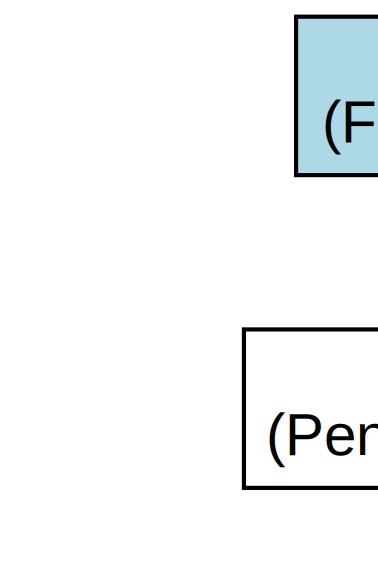

In [ ]:
import graphviz
from IPython.display import display

# 1. Inisialisasi objek Graphviz dengan orientasi dari atas ke bawah (Top-Bottom)
dot = graphviz.Digraph(comment='Alur Penelitian', format='png')
dot.attr(rankdir='TB', size='10,10', dpi='300')
dot.attr('node', shape='box', style='filled', fillcolor='white', fontname='Arial')

# 2. Pembuatan Node (Kotak Tahapan)
# Tahap Awal
dot.node('A', '1. Akuisisi Dataset\n(Face Mask Detection Kaggle)', fillcolor='lightblue')
dot.node('B', '2. Eksplorasi Data\n(Pengecekan Kualitas & Distribusi)')
dot.node('C', '3. Praproses Data\n(Resize 128x128, Normalisasi, Stratified Split)')

# Tahap Skenario Enhancement
dot.node('D1', 'Tanpa Enhancement\n(Citra Asli)', fillcolor='lightyellow')
dot.node('D2', 'Dengan Enhancement\n(CLAHE pada kanal Luminance)', fillcolor='lightyellow')

# Tahap Ekstraksi Fitur
dot.node('E1', 'Ekstraksi Fitur Manual\n(HOG)')
dot.node('E2', 'Ekstraksi Fitur Otomatis\n(Layer Konvolusi)')

# Tahap Klasifikasi
dot.node('F1', 'Klasifikasi SVM\n(Skenario 1 & 2)', fillcolor='lightgreen')
dot.node('F2', 'Klasifikasi CNN\n(Skenario 3 & 4)', fillcolor='lightgreen')

# Tahap Akhir
dot.node('G', 'Evaluasi Performa\n(Accuracy, Precision, Recall, F1-Score)')
dot.node('H', 'Demo Program\n(Inferensi Gambar Baru)', fillcolor='lightgray')

# 3. Penyambungan Garis (Edges)
dot.edge('A', 'B')
dot.edge('B', 'C')

# Percabangan ke status enhancement
dot.edge('C', 'D1')
dot.edge('C', 'D2')

# Percabangan dari status enhancement ke metode ekstraksi
# Dari Tanpa Enhancement
dot.edge('D1', 'E1', label=' Skenario 1')
dot.edge('D1', 'E2', label=' Skenario 3')

# Dari Dengan Enhancement
dot.edge('D2', 'E1', label=' Skenario 2')
dot.edge('D2', 'E2', label=' Skenario 4')

# Menuju klasifikasi
dot.edge('E1', 'F1')
dot.edge('E2', 'F2')

# Menyatukan ke evaluasi
dot.edge('F1', 'G')
dot.edge('F2', 'G')

# Menuju akhir
dot.edge('G', 'H')

# 4. Menyimpan file dan menampilkan diagram di Colab
output_path = 'alur_penelitian_project'
dot.render(output_path, view=False)

print(f"Diagram berhasil dibuat dan disimpan sebagai: {output_path}.png")
display(dot)

## Bagian E — Persiapan Data dan Split

Pemisahan data dilakukan secara *stratified* (mempertahankan proporsi antar kelas) agar mencegah bias. Data dibagi dengan rasio:
1. Data Pelatihan (*Training*): 70%
2. Data Validasi (*Validation*): 15%
3. Data Pengujian (*Testing*): 15%

Langkah ini juga menjamin tidak ada kebocoran data (*data leakage*) antarfase pelatihan dan pengujian.

In [ ]:
# 1. Melakukan Stratified Split: Train (70%), sisa (30%)
train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df['class_id'],
    random_state=SEED
)

# 2. Split sisa menjadi Validation (15%) dan Test (15%)
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df['class_id'],
    random_state=SEED
)

# 3. Menampilkan hasil pembagian
print("Hasil Pembagian Dataset:")
print(f"Data Training   : {len(train_df)} citra")
print(f"Data Validation : {len(val_df)} citra")
print(f"Data Testing    : {len(test_df)} citra")

# 4. Validasi kebocoran data
train_files = set(train_df['filepath'])
val_files = set(val_df['filepath'])
test_files = set(test_df['filepath'])

overlap = train_files.intersection(val_files).union(train_files.intersection(test_files))
print(f"Jumlah file yang tumpang tindih antar set: {len(overlap)}")

Hasil Pembagian Dataset:
Data Training   : 6287 citra
Data Validation : 1347 citra
Data Testing    : 1348 citra
Jumlah file yang tumpang tindih antar set: 0


## Bagian F — Praproses Citra

Setiap citra perlu diseragamkan dimensinya sebelum dimasukkan ke dalam model klasifikasi.
1. Citra akan dibaca menggunakan format RGB.
2. Ukuran citra diubah menjadi 128 x 128 piksel untuk efisiensi komputasi di Google Colab.
3. Fungsi ini akan mengembalikan array NumPy. Normalisasi `/ 255.0` akan diterapkan saat perancangan pipeline model untuk menghemat RAM.

In [ ]:
IMG_SIZE = (128, 128)

def load_and_resize_image(filepath):
    img = cv2.imread(filepath)
    if img is None:
        return np.zeros((IMG_SIZE[0], IMG_SIZE[1], 3), dtype=np.uint8)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, IMG_SIZE)
    return img

print("Membaca citra training...")
X_train_raw = np.array([load_and_resize_image(fp) for fp in train_df['filepath']])
y_train = train_df['class_id'].values

print("Membaca citra validation...")
X_val_raw = np.array([load_and_resize_image(fp) for fp in val_df['filepath']])
y_val = val_df['class_id'].values

print("Membaca citra testing...")
X_test_raw = np.array([load_and_resize_image(fp) for fp in test_df['filepath']])
y_test = test_df['class_id'].values

print(f"Dimensi X_train: {X_train_raw.shape}")

Membaca citra training...
Membaca citra validation...
Membaca citra testing...
Dimensi X_train: (6287, 128, 128, 3)


## Bagian G — Image Enhancement

Pendekatan *enhancement* yang digunakan adalah *Contrast Limited Adaptive Histogram Equalization* (CLAHE) yang dioperasikan pada saluran Luminance (L) dari ruang warna LAB.
Alasan akademik penggunaannya:
1. Citra wajah kerap memiliki area bayangan yang tidak merata. Histogram *equalization* standar akan meningkatkan kontras secara global yang berisiko memperkuat derau (*noise*).
2. CLAHE meningkatkan kontras secara adaptif pada blok kecil, mempertahankan tekstur masker dan kulit tanpa distorsi pencahayaan ekstrem.

Menerapkan enhancement pada dataset...
Enhancement selesai.


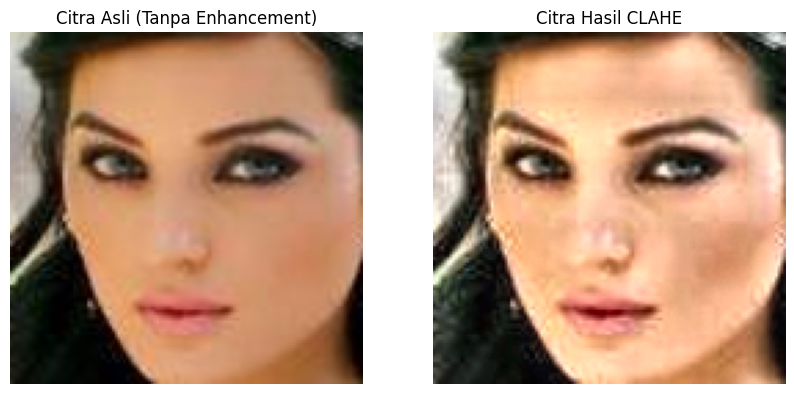

In [ ]:
def apply_clahe(img):
    # Mengubah RGB ke LAB
    lab = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(lab)

    # Menerapkan CLAHE pada kanal L (Luminance)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    cl = clahe.apply(l)

    # Menggabungkan kembali dan konversi ke RGB
    limg = cv2.merge((cl, a, b))
    final_img = cv2.cvtColor(limg, cv2.COLOR_LAB2RGB)
    return final_img

def batch_enhancement(images):
    enhanced = np.zeros_like(images)
    for i in range(images.shape[0]):
        enhanced[i] = apply_clahe(images[i])
    return enhanced

print("Menerapkan enhancement pada dataset...")
X_train_enh = batch_enhancement(X_train_raw)
X_val_enh = batch_enhancement(X_val_raw)
X_test_enh = batch_enhancement(X_test_raw)
print("Enhancement selesai.")

# Visualisasi perbandingan
idx = random.randint(0, len(X_train_raw)-1)
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(X_train_raw[idx])
ax[0].set_title("Citra Asli (Tanpa Enhancement)")
ax[0].axis('off')

ax[1].imshow(X_train_enh[idx])
ax[1].set_title("Citra Hasil CLAHE")
ax[1].axis('off')
plt.show()

## Bagian H — Feature Extraction HOG

Untuk memodelkan algoritma *machine learning* klasik, diperlukan ekstraksi fitur secara manual.
1. Metode yang dipilih adalah *Histogram of Oriented Gradients* (HOG).
2. HOG unggul dalam merepresentasikan kontur objek dan gradien intensitas. Hal ini sangat efektif untuk mendeteksi batas tegas (tepi) antara masker dan wajah manusia.

Mengekstraksi fitur HOG untuk citra tanpa enhancement...
Mengekstraksi fitur HOG untuk citra dengan enhancement...
Ukuran Vektor Fitur HOG per citra: 8100


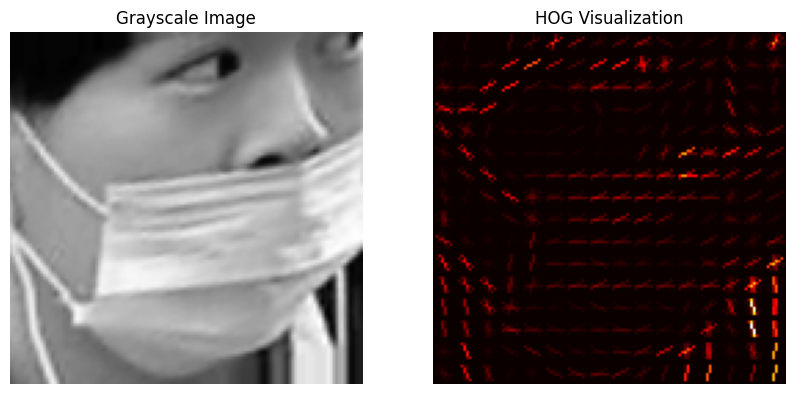

In [ ]:
def extract_hog_features(images):
    features_list = []
    for img in images:
        gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
        # Parameter HOG yang umum digunakan
        features = hog(gray, orientations=9, pixels_per_cell=(8, 8),
                       cells_per_block=(2, 2), block_norm='L2-Hys',
                       transform_sqrt=True, feature_vector=True)
        features_list.append(features)
    return np.array(features_list)

print("Mengekstraksi fitur HOG untuk citra tanpa enhancement...")
X_train_hog_raw = extract_hog_features(X_train_raw)
X_test_hog_raw = extract_hog_features(X_test_raw)

print("Mengekstraksi fitur HOG untuk citra dengan enhancement...")
X_train_hog_enh = extract_hog_features(X_train_enh)
X_test_hog_enh = extract_hog_features(X_test_enh)

print(f"Ukuran Vektor Fitur HOG per citra: {X_train_hog_raw.shape[1]}")

# Visualisasi Fitur HOG
gray_sample = cv2.cvtColor(X_train_raw[0], cv2.COLOR_RGB2GRAY)
fd, hog_image = hog(gray_sample, orientations=9, pixels_per_cell=(8, 8),
                    cells_per_block=(2, 2), block_norm='L2-Hys',
                    visualize=True, transform_sqrt=True)

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(gray_sample, cmap='gray')
ax[0].set_title('Grayscale Image')
ax[0].axis('off')

ax[1].imshow(hog_image, cmap='hot')
ax[1].set_title('HOG Visualization')
ax[1].axis('off')
plt.show()

## Bagian I — Model Klasik HOG dan SVM

Model SVM (*Support Vector Machine*) dilatih untuk membedakan kategori penggunaan masker menggunakan fitur HOG. Dua skenario dijalankan:
1. Skenario 1: Fitur HOG dari gambar asli (tanpa *enhancement*).
2. Skenario 2: Fitur HOG dari gambar yang telah ditingkatkan kualitasnya (dengan *enhancement* CLAHE).


--- Melatih Skenario 1: HOG-SVM (Tanpa Enhancement) ---
Waktu pelatihan: 58.92 detik

Classification Report:
                                       precision    recall  f1-score   support

      Menggunakan masker dengan benar       0.94      0.94      0.94       449
Menggunakan masker dengan tidak tepat       0.98      1.00      0.99       449
             Tidak menggunakan masker       0.96      0.93      0.94       450

                             accuracy                           0.96      1348
                            macro avg       0.96      0.96      0.96      1348
                         weighted avg       0.96      0.96      0.96      1348



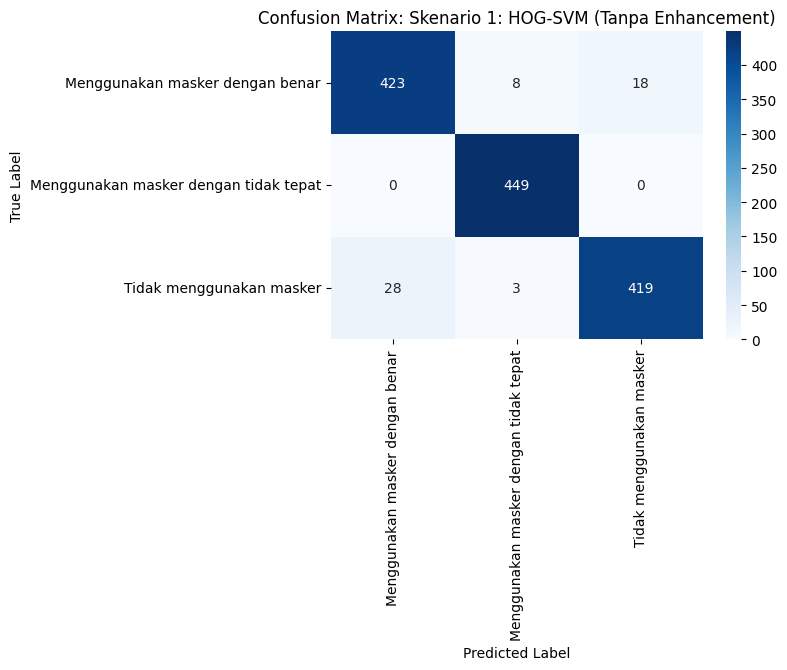


--- Melatih Skenario 2: HOG-SVM (Dengan Enhancement) ---
Waktu pelatihan: 59.58 detik

Classification Report:
                                       precision    recall  f1-score   support

      Menggunakan masker dengan benar       0.92      0.93      0.93       449
Menggunakan masker dengan tidak tepat       0.97      1.00      0.98       449
             Tidak menggunakan masker       0.95      0.92      0.94       450

                             accuracy                           0.95      1348
                            macro avg       0.95      0.95      0.95      1348
                         weighted avg       0.95      0.95      0.95      1348



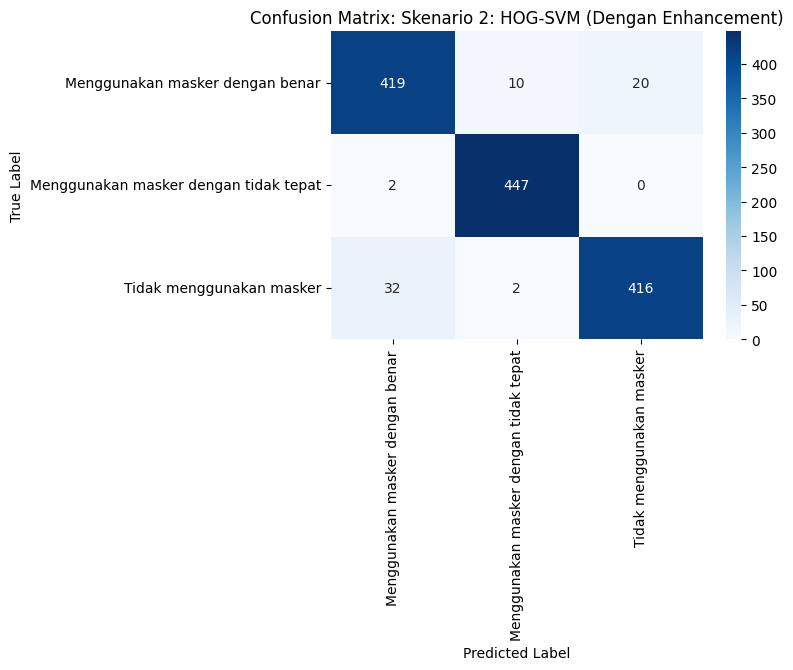

In [ ]:
def train_evaluate_svm(X_train, y_train, X_test, y_test, scenario_name):
    print(f"\n--- Melatih {scenario_name} ---")
    start_time = time.time()

    # Menggunakan Kernel Linear karena dimensi HOG tinggi dan lebih cepat
    svm_model = SVC(kernel='linear', C=1.0, random_state=SEED)
    svm_model.fit(X_train, y_train)

    train_time = time.time() - start_time
    print(f"Waktu pelatihan: {train_time:.2f} detik")

    # Evaluasi
    y_pred = svm_model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='macro', zero_division=0)
    rec = recall_score(y_test, y_pred, average='macro', zero_division=0)
    f1 = f1score = f1_score(y_test, y_pred, average='macro', zero_division=0)

    print("\nClassification Report:")
    target_names = [id_to_class[i] for i in range(len(unique_labels))]
    print(classification_report(y_test, y_pred, target_names=target_names))

    # Visualisasi Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
    plt.title(f'Confusion Matrix: {scenario_name}')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()

    return {
        'Model': 'HOG-SVM',
        'Enhancement': 'Ya' if 'Dengan' in scenario_name else 'Tidak',
        'Accuracy': acc,
        'Precision (Macro)': prec,
        'Recall (Macro)': rec,
        'F1-Score (Macro)': f1,
        'Waktu Training (s)': round(train_time, 2)
    }, svm_model

# Eksekusi Skenario 1
result_s1, model_svm_raw = train_evaluate_svm(
    X_train_hog_raw, y_train, X_test_hog_raw, y_test, "Skenario 1: HOG-SVM (Tanpa Enhancement)"
)

# Eksekusi Skenario 2
result_s2, model_svm_enh = train_evaluate_svm(
    X_train_hog_enh, y_train, X_test_hog_enh, y_test, "Skenario 2: HOG-SVM (Dengan Enhancement)"
)

## Bagian J — Persiapan Dataset TensorFlow

Tahapan ini mengonversi matriks memori ke bentuk `tf.data.Dataset` yang efisien.
1. Normalisasi fitur (membagi nilai piksel dengan 255.0) diterapkan.
2. Data dikemas ke dalam *batch* berukuran 32.
3. Fungsi prapemrosesan ini digunakan untuk data eksperimen CNN.

In [ ]:
BATCH_SIZE = 32

def create_tf_dataset(X, y, is_training=False):
    # Normalisasi tipe data ke float32 (0-1)
    X_norm = X.astype(np.float32) / 255.0

    dataset = tf.data.Dataset.from_tensor_slices((X_norm, y))

    if is_training:
        dataset = dataset.shuffle(buffer_size=len(X))

    dataset = dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return dataset

# Dataset Tanpa Enhancement
train_ds_raw = create_tf_dataset(X_train_raw, y_train, is_training=True)
val_ds_raw = create_tf_dataset(X_val_raw, y_val, is_training=False)
test_ds_raw = create_tf_dataset(X_test_raw, y_test, is_training=False)

# Dataset Dengan Enhancement
train_ds_enh = create_tf_dataset(X_train_enh, y_train, is_training=True)
val_ds_enh = create_tf_dataset(X_val_enh, y_val, is_training=False)
test_ds_enh = create_tf_dataset(X_test_enh, y_test, is_training=False)

print("TensorFlow datasets berhasil diinisialisasi.")

TensorFlow datasets berhasil diinisialisasi.


## Bagian K — Model CNN Sederhana

Arsitektur CNN dibuat sendiri dari awal (*from scratch*).
1. `Data Augmentation` disisipkan di dalam model (hanya aktif saat fase *training*) guna memperkaya variasi citra.
2. Tiga blok konvolusi (`Conv2D` + `MaxPooling2D`) digunakan untuk mengekstraksi fitur level rendah hingga tinggi.
3. `Flatten` dan `Dense` layer digunakan sebagai tahap klasifikasi akhir, ditutup dengan fungsi aktivasi `softmax`.
4. *Early Stopping* diterapkan guna mencegah *overfitting* apabila model tidak menunjukkan perbaikan kinerja.

In [ ]:
def build_cnn_model(num_classes):
    # Layer augmentasi internal
    data_augmentation = tf.keras.Sequential([
        layers.RandomFlip("horizontal", seed=SEED),
        layers.RandomRotation(0.1, seed=SEED),
        layers.RandomZoom(0.1, seed=SEED),
    ], name="augmentation_layer")

    model = models.Sequential([
        layers.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3)),
        data_augmentation,

        layers.Conv2D(32, (3, 3), activation='relu'),
        layers.MaxPooling2D(pool_size=(2, 2)),

        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.MaxPooling2D(pool_size=(2, 2)),

        layers.Conv2D(128, (3, 3), activation='relu'),
        layers.MaxPooling2D(pool_size=(2, 2)),

        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.5, seed=SEED),
        layers.Dense(num_classes, activation='softmax')
    ])

    model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model

# Callback pengaman
early_stop = callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
EPOCHS = 15

print("Arsitektur CNN siap. Memulai pelatihan...")

# --- Skenario 3: CNN Tanpa Enhancement ---
print("\n--- Melatih Skenario 3: CNN (Tanpa Enhancement) ---")
cnn_model_raw = build_cnn_model(len(unique_labels))

start_time = time.time()
history_raw = cnn_model_raw.fit(
    train_ds_raw,
    validation_data=val_ds_raw,
    epochs=EPOCHS,
    callbacks=[early_stop],
    verbose=1
)
time_cnn_raw = time.time() - start_time

# --- Skenario 4: CNN Dengan Enhancement ---
print("\n--- Melatih Skenario 4: CNN (Dengan Enhancement) ---")
cnn_model_enh = build_cnn_model(len(unique_labels))

start_time = time.time()
history_enh = cnn_model_enh.fit(
    train_ds_enh,
    validation_data=val_ds_enh,
    epochs=EPOCHS,
    callbacks=[early_stop],
    verbose=1
)
time_cnn_enh = time.time() - start_time

Arsitektur CNN siap. Memulai pelatihan...

--- Melatih Skenario 3: CNN (Tanpa Enhancement) ---
Epoch 1/15
197/197 ━━━━━━━━━━━━━━━━━━━━ 211s 1s/step - accuracy: 0.7912 - loss: 0.5107 - val_accuracy: 0.8961 - val_loss: 0.2874
Epoch 2/15
197/197 ━━━━━━━━━━━━━━━━━━━━ 257s 1s/step - accuracy: 0.8885 - loss: 0.2960 - val_accuracy: 0.9191 - val_loss: 0.2263
Epoch 3/15
197/197 ━━━━━━━━━━━━━━━━━━━━ 202s 1s/step - accuracy: 0.9170 - loss: 0.2369 - val_accuracy: 0.9510 - val_loss: 0.1496
Epoch 4/15
197/197 ━━━━━━━━━━━━━━━━━━━━ 201s 1s/step - accuracy: 0.9335 - loss: 0.1915 - val_accuracy: 0.9428 - val_loss: 0.1678
Epoch 5/15
197/197 ━━━━━━━━━━━━━━━━━━━━ 203s 1s/step - accuracy: 0.9472 - loss: 0.1522 - val_accuracy: 0.9592 - val_loss: 0.1100
Epoch 6/15
197/197 ━━━━━━━━━━━━━━━━━━━━ 202s 1s/step - accuracy: 0.9485 - loss: 0.1448 - val_accuracy: 0.9621 - val_loss: 0.1217
Epoch 7/15
197/197 ━━━━━━━━━━━━━━━━━━━━ 202s 1s/step - accuracy: 0.9532 - loss: 0.1347 - val_accuracy: 0.9762 - val_loss: 0.0763
Ep

## Bagian L — Evaluasi CNN

Evaluasi CNN dilakukan dengan melakukan inferensi pada data *testing*. Grafik pergerakan *accuracy* dan *loss* akan diplot untuk mendeteksi adanya *underfitting* atau *overfitting* selama proses pelatihan.


--- Evaluasi Skenario 3: CNN (Tanpa Enhancement) ---


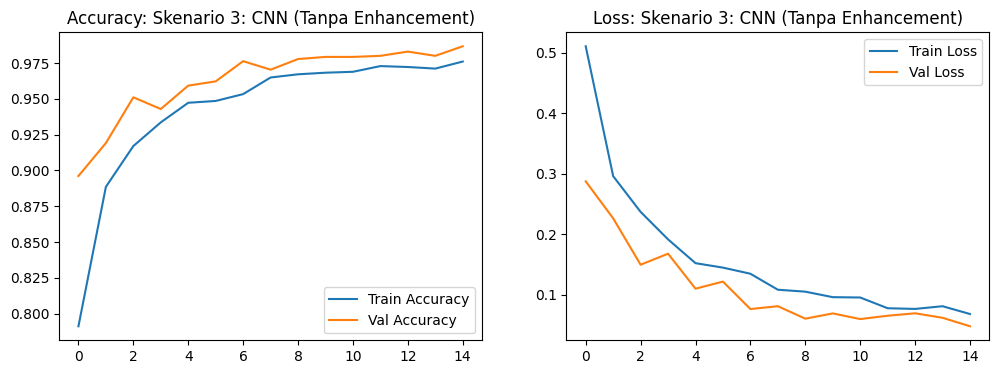

43/43 ━━━━━━━━━━━━━━━━━━━━ 11s 261ms/step

Classification Report:
                                       precision    recall  f1-score   support

      Menggunakan masker dengan benar       0.99      0.98      0.99       449
Menggunakan masker dengan tidak tepat       0.98      1.00      0.99       449
             Tidak menggunakan masker       1.00      0.98      0.99       450

                             accuracy                           0.99      1348
                            macro avg       0.99      0.99      0.99      1348
                         weighted avg       0.99      0.99      0.99      1348



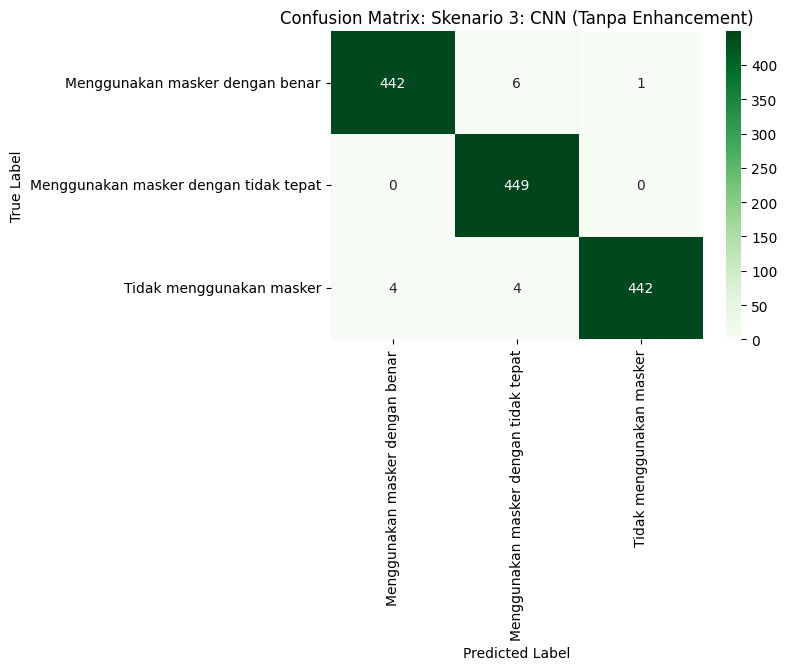


--- Evaluasi Skenario 4: CNN (Dengan Enhancement) ---


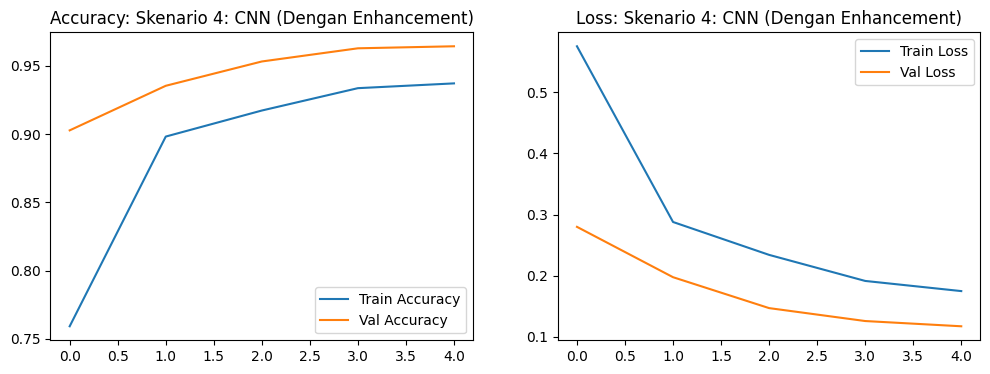

43/43 ━━━━━━━━━━━━━━━━━━━━ 13s 280ms/step

Classification Report:
                                       precision    recall  f1-score   support

      Menggunakan masker dengan benar       0.87      0.92      0.89       449
Menggunakan masker dengan tidak tepat       0.94      0.82      0.87       449
             Tidak menggunakan masker       0.91      0.97      0.94       450

                             accuracy                           0.90      1348
                            macro avg       0.91      0.90      0.90      1348
                         weighted avg       0.91      0.90      0.90      1348



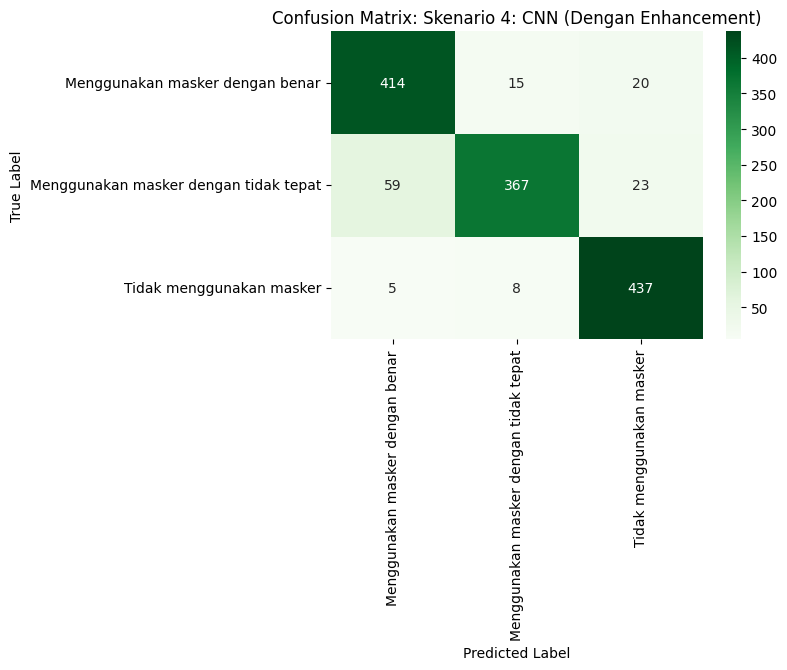

In [ ]:
def evaluate_cnn(model, test_ds, y_true, history, scenario_name, train_time):
    print(f"\n--- Evaluasi {scenario_name} ---")

    # Kurva Pembelajaran
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Plot Accuracy
    axes[0].plot(history.history['accuracy'], label='Train Accuracy')
    axes[0].plot(history.history['val_accuracy'], label='Val Accuracy')
    axes[0].set_title(f'Accuracy: {scenario_name}')
    axes[0].legend()

    # Plot Loss
    axes[1].plot(history.history['loss'], label='Train Loss')
    axes[1].plot(history.history['val_loss'], label='Val Loss')
    axes[1].set_title(f'Loss: {scenario_name}')
    axes[1].legend()
    plt.show()

    # Evaluasi Test
    y_pred_probs = model.predict(test_ds)
    y_pred = np.argmax(y_pred_probs, axis=1)

    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='macro', zero_division=0)
    rec = recall_score(y_true, y_pred, average='macro', zero_division=0)
    f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)

    target_names = [id_to_class[i] for i in range(len(unique_labels))]
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=target_names))

    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', xticklabels=target_names, yticklabels=target_names)
    plt.title(f'Confusion Matrix: {scenario_name}')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()

    return {
        'Model': 'CNN',
        'Enhancement': 'Ya' if 'Dengan' in scenario_name else 'Tidak',
        'Accuracy': acc,
        'Precision (Macro)': prec,
        'Recall (Macro)': rec,
        'F1-Score (Macro)': f1,
        'Waktu Training (s)': round(train_time, 2)
    }

result_s3 = evaluate_cnn(cnn_model_raw, test_ds_raw, y_test, history_raw, "Skenario 3: CNN (Tanpa Enhancement)", time_cnn_raw)
result_s4 = evaluate_cnn(cnn_model_enh, test_ds_enh, y_test, history_enh, "Skenario 4: CNN (Dengan Enhancement)", time_cnn_enh)

## Bagian M — Tabel Perbandingan Seluruh Skenario

Tabel komprehensif dirangkum untuk menyajikan metrik performa keempat skenario secara objektif. Baris akan diurutkan berdasarkan skor akurasi tertinggi untuk menyimpulkan kombinasi metode yang paling efektif.

In [ ]:
# 1. Menggabungkan semua hasil
results_df = pd.DataFrame([result_s1, result_s2, result_s3, result_s4])

# 2. Mengurutkan berdasarkan F1-Score dan Akurasi
results_df = results_df.sort_values(by=['F1-Score (Macro)', 'Accuracy'], ascending=[False, False]).reset_index(drop=True)

print("Tabel Perbandingan Skenario Eksperimen:")
display(results_df)

# Menemukan model terbaik untuk digunakan di demo
best_model_name = results_df.iloc[0]['Model']
best_enh_status = results_df.iloc[0]['Enhancement']
print(f"\nKesimpulan: Model dengan performa terbaik adalah {best_model_name} dengan status Enhancement = {best_enh_status}.")

Tabel Perbandingan Skenario Eksperimen:


,Model,Enhancement,Accuracy,Precision (Macro),Recall (Macro),F1-Score (Macro),Waktu Training (s)
0,CNN,Tidak,0.988872,0.988996,0.988877,0.988873,3093.49
1,HOG-SVM,Tidak,0.957715,0.957604,0.957735,0.957552,58.92
2,HOG-SVM,Ya,0.951039,0.950976,0.951058,0.950893,59.58
3,CNN,Ya,0.903561,0.905850,0.903511,0.902613,1035.91



Kesimpulan: Model dengan performa terbaik adalah CNN dengan status Enhancement = Tidak.


## Bagian N — Analisis Kesalahan Prediksi

Observasi ini meninjau gambar-gambar dari data pengujian yang gagal diklasifikasi dengan benar. Kemungkinan penyebab kegagalan klasifikasi antara lain:
1. Posisi wajah ekstrem (menyamping tajam).
2. Terdapat tangan yang menutupi area wajah (*oklusi*).
3. Masker memiliki pola yang terlalu menyerupai warna kulit.
4. Latar belakang yang sangat mengganggu deteksi wajah.

43/43 ━━━━━━━━━━━━━━━━━━━━ 11s 258ms/step
Ditemukan 130 kesalahan prediksi pada CNN dengan Enhancement.


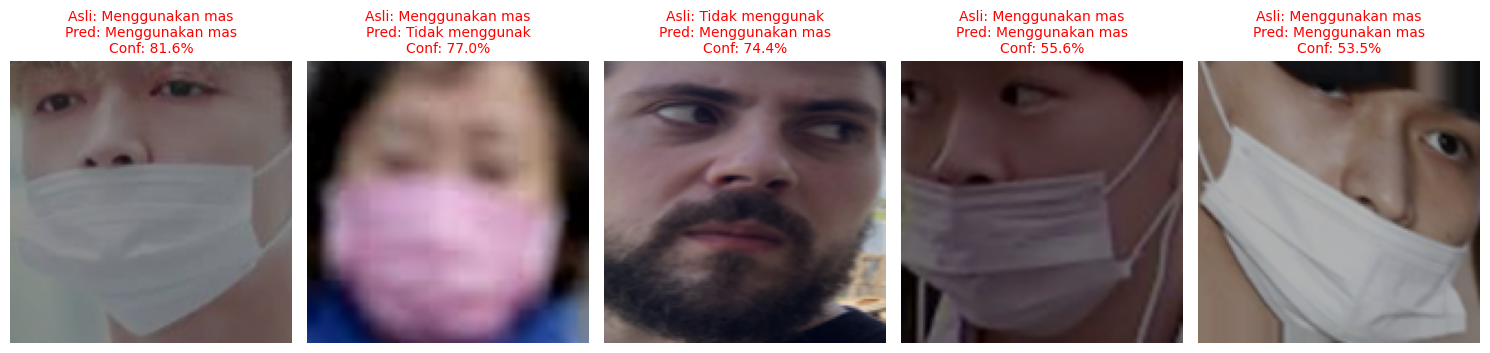

In [ ]:
# 1. Melakukan prediksi menggunakan model CNN hasil terbaik (misal kita gunakan cnn_model_enh jika bagus, atau raw)
# Kita evaluasi dari cnn_model_enh untuk visualisasi ini
y_pred_probs_enh = cnn_model_enh.predict(test_ds_enh)
y_pred_enh = np.argmax(y_pred_probs_enh, axis=1)

# 2. Mencari indeks kesalahan
errors_idx = np.where(y_pred_enh != y_test)[0]

print(f"Ditemukan {len(errors_idx)} kesalahan prediksi pada CNN dengan Enhancement.")

# 3. Menampilkan sebagian dari sampel yang salah (Maksimal 5)
num_display = min(5, len(errors_idx))
if num_display > 0:
    fig, axes = plt.subplots(1, num_display, figsize=(15, 4))
    if num_display == 1:
        axes = [axes]

    for i, idx in enumerate(errors_idx[:num_display]):
        img = X_test_raw[idx]  # Tampilkan gambar aslinya agar mudah dilihat manusia
        true_label = id_to_class[y_test[idx]]
        pred_label = id_to_class[y_pred_enh[idx]]
        confidence = np.max(y_pred_probs_enh[idx]) * 100

        axes[i].imshow(img)
        title = f"Asli: {true_label[:15]}\nPred: {pred_label[:15]}\nConf: {confidence:.1f}%"
        axes[i].set_title(title, fontsize=10, color='red')
        axes[i].axis('off')

    plt.tight_layout()
    plt.show()
else:
    print("Tidak ada kesalahan prediksi yang ditemukan!")

## Bagian O — Demo Prediksi Gambar Baru

Bagian ini memungkinkan pengguna mengunggah gambar wajah mereka sendiri. Program akan menerapkan praproses, *enhancement*, dan memprediksi kondisi penggunaan masker melalui model CNN terbaik yang telah dilatih.

Sedang memproses gambar: jokowi.png
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 274ms/step


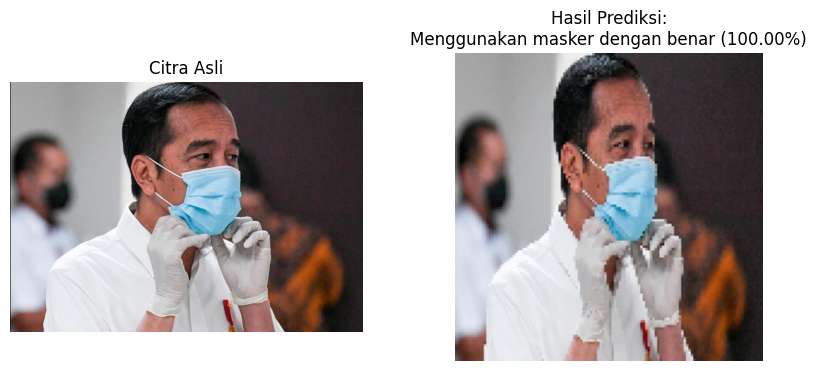

In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from PIL import Image

def predict_local_image(model, image_path, with_enhancement=False):
    print(f"Sedang memproses gambar: {image_path}")
    try:
        # Membaca gambar lokalan
        img = Image.open(image_path).convert('RGB')
        img_np = np.array(img)

        # Resize sesuai input model 128x128
        img_resized = cv2.resize(img_np, (128, 128))

        # Gunakan citra asli tanpa enhancement karena Skenario 3 adalah yang terbaik
        if with_enhancement:
            processed_img = apply_clahe(img_resized)
        else:
            processed_img = img_resized

        # Normalisasi dan inferensi model
        model_input = np.expand_dims(processed_img.astype(np.float32) / 255.0, axis=0)
        prediction_probs = model.predict(model_input)[0]
        predicted_class_id = np.argmax(prediction_probs)
        confidence = prediction_probs[predicted_class_id] * 100
        label_text = id_to_class[predicted_class_id]

        # Menampilkan visualisasi hasil berdampingan
        fig, ax = plt.subplots(1, 2, figsize=(10, 4))
        ax[0].imshow(img_np)
        ax[0].set_title("Citra Asli")
        ax[0].axis('off')

        ax[1].imshow(processed_img)
        ax[1].set_title(f"Hasil Prediksi:\n{label_text} ({confidence:.2f}%)")
        ax[1].axis('off')
        plt.show()

    except FileNotFoundError:
        print(f"Error: File '{image_path}' tidak ditemukan. Pastikan file foto sudah Anda seret/upload ke panel kiri Colab.")

# Eksekusi langsung ke file jokowi.png menggunakan model cnn_model_raw (Skenario 3 Terbaik)
predict_local_image(cnn_model_raw, 'jokowi.png', with_enhancement=False)